# Automatic Music Transcription
* Audio to guitar tablature

# TODO
* Consider using an embedding layer at the input, as it can help in learning a more meaningful representation of the tokens


In [75]:
# install relevant packages for Google Colab
# !pip install pyguitarpro
# !pip install --upgrade attrs
# !pip install accelerate -U
# !pip install datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.1/507.1 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 14.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 15.7 MB/s eta 0:00:00


In [1]:
from __future__ import unicode_literals, print_function, division
from io import open
import unicodedata
import re
import random
from sklearn.model_selection import train_test_split
import IPython.display as ipd

import copy
import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F


from torch.nn import TransformerEncoder, TransformerEncoderLayer
import math

import numpy as np
from torch.utils.data import TensorDataset, DataLoader, RandomSampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
device, torch.__version__

(device(type='cuda'), '2.1.2')

In [3]:
import torch
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.__version__)

True
12.1
2.1.2


### Preprocessing

In [4]:
# Load in the mp3 file, get the sample rate, and get the data
# from the file

import numpy as np
import matplotlib.pyplot as plt
import librosa

# Load in the mp3 file
filepath = 'dataset/john-mayer/3_Why_Georgia.mp3'
# filepath = '30_Why_Georgia.mp3'
sr = 16000
y, sr = librosa.load(filepath, sr=sr)

In [5]:
# Get the data from the file
data = librosa.feature.mfcc(y=y, sr=sr)

In [7]:
len(y)

4303678

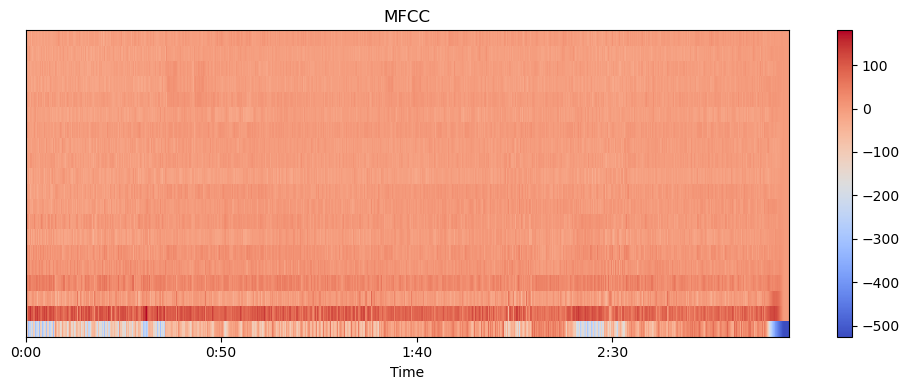

In [8]:
def plotMFCC(data):
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(data, x_axis='time')
    plt.colorbar()
    plt.title('MFCC')
    plt.tight_layout()
    plt.show()

plotMFCC(data)

In [9]:
import guitarpro

# Load in the gp5 file
tab_filepath = 'dataset/john-mayer/3_why-georgia.gp5'
song = guitarpro.parse(tab_filepath)

In [10]:
def tokenize_note_simple(note):
    """
    Tokenizes a note based on its string and fret number.
    """

    string = note.string
    value = note.value

    # Add pre-conditions for the note
    if string < 1 or string > 6:
        raise ValueError(f"Invalid string number: {string}")

    if value < 0 or value > 20:
        raise ValueError(f"Invalid fret number: {value}")

    # Calculate the token index based on string and fret
    # Token range for fretted notes: 1 to 120
    # Token range for open strings: 121 to 126
    if value == 0:  # Open string
        token_index = 121 + (6 - string)
    else:
        token_index = (string - 1) * 20 + value

    return token_index

In [11]:
from guitarpro.models import Note, Beat
beat = Beat(voice=None)
g_note = Note(beat, string=6, value=3)

tokenize_note_simple(g_note)

103

In [12]:
def detokenize_note_simple(token_index):
    """
    Detokenizes a token index to find the corresponding guitar string and fret number.
    @TODO: Return note object rather than string
    """

    # Pre-conditions for the token index
    if token_index < 1 or token_index > 129:
        raise ValueError(f"Invalid token index: {token_index}")

    # Determining the string and fret based on token index
    if 121 <= token_index <= 126:  # Open string
        string = 6 - (token_index - 121)
        fret = 0
    elif token_index == 127:
        return "wait"
    elif token_index == 128:
        return "start"
    elif token_index == 129:
        return "end"
    else:
        string = ((token_index - 1) // 20) + 1
        fret = token_index - ((string - 1) * 20)

    return f"s{string}f{fret}"

# Example usage
note_info = detokenize_note_simple(126)
print(note_info)


s1f0


In [13]:
detokenize_note_simple(1)

's1f1'

In [14]:
label2id = {}
id2label = {}

vocab_size = 129

for token_idx in range(1,vocab_size+1):
  label = detokenize_note_simple(token_idx)
  label2id[label] = token_idx
  id2label[token_idx] = label


In [15]:
label2id['s1f0'], id2label[126]


(126, 's1f0')

In [16]:
def tokenize_song_simple(song):
    """
    Tokenizes an entire song using a simplified scheme.
    """
    all_measures_tokens = []

    # Start token for the song
    all_measures_tokens.append([128])  # 128 is the start token

    for track in song.tracks:
        for measure in track.measures:
            measure_tokens = []
            for voice in measure.voices:
                for beat in voice.beats:
                    if track.isPercussionTrack:
                        continue  # Skip percussion tracks
                    else:
                        for note in beat.notes:
                            token = tokenize_note_simple(note)
                            measure_tokens.append(token)

                    # Assuming each beat is a 'wait' token
                    measure_tokens.append(127)  # 127 is the wait/rest token

            # Repeat measures if necessary
            if measure.repeatClose > 0:
                for _ in range(measure.repeatClose):
                    all_measures_tokens.append(measure_tokens)
            else:
                all_measures_tokens.append(measure_tokens)

    # End token for the song
    all_measures_tokens.append([129])  # 129 is the end token

    return all_measures_tokens

In [17]:
# visualize the simple note tokenizer
from IPython.display import Image
# Image(filename='research/simple-note-tokenizer.jpg', width=500)

In [18]:
# tokenize the acoustic song track only
acoustic_song = copy.deepcopy(song)
acoustic_song.tracks = [acoustic_song.tracks[0]]

tokens = tokenize_song_simple(acoustic_song)

In [19]:
min_token_value = min([min(measure) for measure in tokens])
max_token_value = max([max(measure) for measure in tokens])
print(f"Min token value: {min_token_value}")
print(f"Max token value: {max_token_value}")

Min token value: 2
Max token value: 129


In [20]:
def count_acoustic_notes():
    acoustic_notes = []
    max_num_notes = 5
    counter = 0

    for track in acoustic_song.tracks:
        for measure in track.measures:
            for voice in measure.voices:
                for beat in voice.beats:
                    for note in beat.notes:
                        acoustic_notes.append(note)

                        counter += 1
                        if counter > max_num_notes:
                            return acoustic_notes

acoustic_notes = count_acoustic_notes()
len(acoustic_notes), acoustic_notes[:5]
for note in acoustic_notes[:5]:
    print(f'Token: {tokenize_note_simple(note)} for note: s{note.string} f{note.value}')

Token: 123 for note: s4 f0
Token: 122 for note: s5 f0
Token: 103 for note: s6 f3
Token: 23 for note: s2 f3
Token: 124 for note: s3 f0


In [21]:
# Initialize an empty dictionary to store the mapping from tokens to integers
token_to_int = {}
int_to_token = {}
next_int = 0  # Start assigning from 0

# Function to dynamically update the dictionary
def update_token_mapping(token, token_to_int, int_to_token, next_int):
    if token not in token_to_int:
        token_to_int[token] = next_int
        int_to_token[next_int] = token
        next_int += 1
    return next_int

# Update the dictionary with the tokens from the file
for measure in tokens:
    for token in measure:
        next_int = update_token_mapping(token, token_to_int, int_to_token, next_int)

# Show some statistics and samples to verify
num_unique_tokens = len(token_to_int)
sample_items_token_to_int = list(token_to_int.items())[:5]
sample_items_int_to_token = list(int_to_token.items())[:5]

num_unique_tokens, sample_items_token_to_int, sample_items_int_to_token
print(f'num_unique_tokens: {num_unique_tokens}')
print(f'Token to int: {sample_items_token_to_int}')
print(f'Int to token: {sample_items_int_to_token}')


num_unique_tokens: 37
Token to int: [(128, 0), (127, 1), (123, 2), (122, 3), (103, 4)]
Int to token: [(0, 128), (1, 127), (2, 123), (3, 122), (4, 103)]


In [22]:
# Convert the tokens to their corresponding integer values using the mapping
# integer_representation = [token_to_int[token] for token in tokens]

token_measures = []
for measure in tokens:
    integer_representation = []
    for token in measure:
        integer_representation.append(token_to_int[token])
    token_measures.append(integer_representation)

In [23]:
# convert the integer representation back to the original tokens
reconstructed_tokens = []
for measure in token_measures:
    reconstructed_tokens.append([int_to_token[i] for i in measure])

## Audio Segmentation
* Split the audio into segments of roughly the same length as the tablature measures.

In [24]:
len(y), sr

(4303678, 16000)

In [25]:
# Given parameters
sample_rate = sr
chunk_duration = 2.5  # Chunk duration in seconds
hop_length = 512  # This is the default hop length for librosa's mfcc calculation

# Calculate the number of samples per chunk
samples_per_chunk = int(sample_rate * chunk_duration)

# Calculate the number of chunks
num_chunks = len(y) // samples_per_chunk + 1

# calculate total number of frames
total_frames = len(y) // hop_length + 1

# Calculate the number of frames per chunk
# Formula: Number of Frames = (Number of Samples in Segment - Frame Length) / Hop Length + 1
# Assuming the frame length is equal to the hop length for simplicity
frames_per_chunk = (samples_per_chunk) // hop_length + 1

In [26]:
samples_per_chunk, num_chunks, frames_per_chunk

(40000, 108, 79)

In [27]:
# Assuming 'y' is your original audio waveform
audio_segments = []
# let start be at the 0.5 second mark
start = int(0.5 * sample_rate)
for start_frame in range(start, len(y), frames_per_chunk * hop_length):
    end_frame = start_frame + frames_per_chunk * hop_length
    segment = y[start_frame:end_frame]
    audio_segments.append(segment)

# 'audio_segments' now contains chunks of the original audio waveform

In [31]:
segmented_evenly = abs(len(token_measures) - len(audio_segments)) < 3
# assert(segmented_evenly)        # make sure the audio segments and measures are segmented evenly
print(len(token_measures), len(audio_segments))

108 107


In [32]:
measure_num = 2
audio_segment_num = 0

# get the audio segment
audio_segment = audio_segments[audio_segment_num]

# play the audio segment
ipd.Audio(audio_segment, rate=sample_rate)
# reconstructed_tokens[measure_num]

In [33]:
print(len(token_measures), len(audio_segments))

108 107


In [34]:
# delete the first two measures which are the song metadata and initial wait token
del token_measures[:2]      # @TODO: TEST THIS!!!

In [35]:
audio_segment_num = 10
measure_num = audio_segment_num

# get the audio segment
audio_segment = audio_segments[audio_segment_num]
# get the measure
measure = token_measures[measure_num]
print(audio_segment)
print(measure)
print(len(audio_segment), len(measure))

[-0.02659272 -0.03568982 -0.03426714 ...  0.15715042  0.14725682
  0.12436663]
[2, 3, 4, 1, 5, 6, 1, 7, 1, 3, 8, 1, 5, 6, 1, 3, 1, 9, 10, 1, 6, 1, 2, 3, 1, 10, 1, 9, 1, 6, 1]
40448 31


In [36]:
# show the tokens
reconstructed_tokens[measure_num]

[83,
 127,
 23,
 44,
 62,
 127,
 83,
 127,
 23,
 42,
 62,
 127,
 65,
 127,
 62,
 127,
 83,
 127,
 23,
 42,
 62,
 127,
 65,
 127,
 83,
 127,
 23,
 42,
 62,
 127,
 123,
 122,
 127,
 62,
 127,
 23,
 42,
 62,
 127,
 44,
 127]

In [37]:
# play the first measure audio segment
ipd.Audio(audio_segment, rate=sample_rate)

## Dataset

107 20 (20, 80)


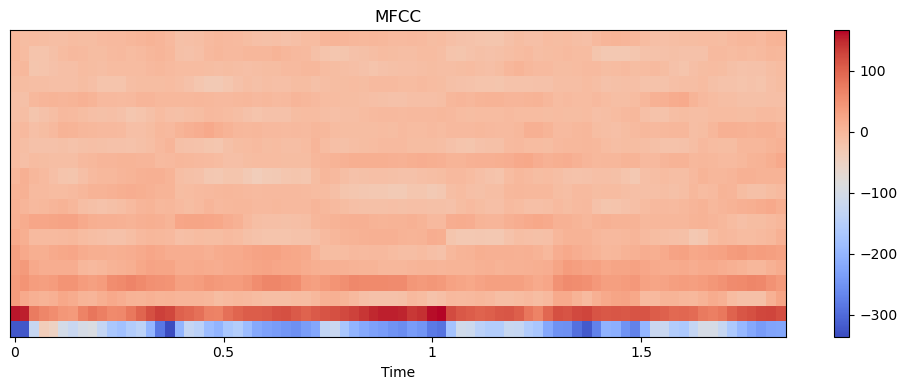

In [38]:
len(audio_segments)

# get the MFCC for the first 10 audio segments
audio_segments_mfcc = []
for audio_segment in audio_segments:
    audio_segments_mfcc.append(librosa.feature.mfcc(y=audio_segment, sr=sample_rate))

print(len(audio_segments_mfcc), len(audio_segments_mfcc[0]), audio_segments_mfcc[0].shape)

# plot the MFCC for the first audio segments
plotMFCC(audio_segments_mfcc[0])

In [39]:
audio_segments_mfcc = audio_segments_mfcc[:audio_segment_num]

In [40]:
len(audio_segments_mfcc), len(y)

(10, 4303678)

In [41]:
for audio_seg in audio_segments_mfcc:
  print(audio_seg.shape)

(20, 80)
(20, 80)
(20, 80)
(20, 80)
(20, 80)
(20, 80)
(20, 80)
(20, 80)
(20, 80)
(20, 80)


In [42]:
X = torch.tensor(audio_segments_mfcc)
y = token_measures[:audio_segment_num]

/tmp/ipykernel_23966/3583071793.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /opt/conda/conda-bld/pytorch_1702400430266/work/torch/csrc/utils/tensor_new.cpp:261.)
  X = torch.tensor(audio_segments_mfcc)


In [43]:
X.shape, len(y), len(y[0])

(torch.Size([10, 20, 80]), 10, 31)

In [44]:
for target_tokens in y:
  print(len(target_tokens))

31
31
31
31
31
31
31
41
41
31


In [45]:
# Split the data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Now X_train, y_train are the training set, and X_test, y_test are the test set
X_train, X_test, y_train, y_test

(tensor([[[-7.7042e+01, -6.2424e+01, -7.3380e+01,  ..., -5.0993e+01,
           -4.5859e+01, -7.2811e+01],
          [ 8.4281e+01,  7.7016e+01,  6.3810e+01,  ...,  9.3934e+01,
            1.0461e+02,  1.0438e+02],
          [-1.2350e+01, -2.1403e+01, -2.5190e+01,  ..., -4.8288e+01,
           -5.2095e+01, -3.9531e+01],
          ...,
          [-6.1741e+00, -1.0797e+01, -6.0265e+00,  ..., -5.1236e+00,
           -3.6100e+00, -7.6986e+00],
          [ 5.0767e-03,  1.7926e-01,  1.4861e+00,  ..., -1.3058e+01,
           -9.9371e+00, -9.8296e+00],
          [-9.8427e-01, -3.8928e+00, -8.1635e+00,  ...,  1.8306e-01,
            1.1263e-01, -1.2487e+00]],
 
         [[-3.2278e+02, -3.2423e+02, -1.2553e+02,  ..., -2.3930e+02,
           -2.2717e+02, -2.2440e+02],
          [ 1.5659e+02,  1.5437e+02,  7.4594e+01,  ...,  1.2614e+02,
            1.2743e+02,  1.1963e+02],
          [ 3.8448e+01,  1.8891e+01,  9.8642e+00,  ..., -1.5191e+01,
            8.3597e+00,  2.5405e+01],
          ...,
    

In [46]:
for transcription in y_train:
    print(len(transcription))

31
31
41
31
31
31
31
31


In [47]:
# get the first audio segment
audio_segment_mfcc = X_train[0]
audio_segment_mfcc.shape

torch.Size([20, 80])



Can you explain the audio segment shape again to me?

Certainly! Let's break down the shapes of the audio segment and its Mel-Frequency Cepstral Coefficients (MFCC) representation that you mentioned:

Original Audio Segment MFCC Shape (torch.Size([20, 109])):
    This shape indicates that the MFCC representation of your audio segment is a two-dimensional array.
    The first dimension (20) represents the number of MFCC features. This typically corresponds to the number of coefficients that are used to represent each frame of audio.
    The second dimension (109) represents the number of frames in your audio segment. Each frame is a short snippet of audio, and the entire segment is divided into these frames for analysis.

The time represented by each frame in an MFCC (Mel Frequency Cepstral Coefficients) analysis depends on two key parameters: the frame size and the hop length, both usually defined in terms of samples.

Frame Size: This is the number of samples considered for each analysis window when computing the MFCCs. It defines the duration of the audio segment analyzed in each frame.

Hop Length: This is the number of samples by which the analysis window is shifted after each frame. The hop length determines the time interval between the starts of consecutive frames.

To calculate the time duration of each frame, you need the frame size and the audio's sampling rate. The formula is

$$Frame Duration (seconds) = \frac{Frame Size (samples)}{Sampling Rate (samples/second)}$$

For instance, if your frame size is 512 samples and your audio's sampling rate is 16000 Hz (samples per second), the duration of each frame would be:

$$Frame Duration=\frac{512 samples}{16000 samples/second}=0.032 seconds=32 milliseconds$$

Similarly, the hop length (in samples) can be converted to time (in seconds) using the sampling rate, to find out the time difference between the starts of consecutive frames.


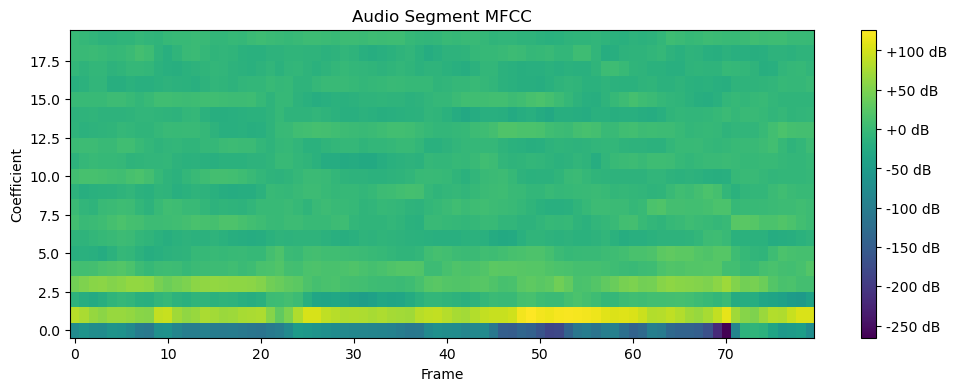

In [48]:
import matplotlib.pyplot as plt
import librosa.display
import numpy as np

# Assuming `audio_segment_mfcc` is your MFCC data with shape (20, 109)
plt.figure(figsize=(12, 4))
plt.imshow(audio_segment_mfcc, aspect='auto', origin='lower',
           interpolation='nearest')
plt.title('Audio Segment MFCC')
plt.xlabel('Frame')
plt.ylabel('Coefficient')
plt.colorbar(format='%+2.0f dB')
plt.show()



I'm a little confused by this plot. I see frames in the x-axis, coefficients in the y-axis ranging from 0 to around 17.5 or 20, and then on the right side of the plot the pixel intensity is represented by dB ranging from +100 dB to -300 dB. Can you explain what's going on? ChatGPT

Certainly! The plot you're looking at is a visual representation of the Mel Frequency Cepstral Coefficients (MFCCs) for an audio segment. Let's break down what each part of the plot represents:

X-Axis (Frames): The horizontal axis represents time, but rather than showing time in seconds, it's divided into frames. In audio processing, a frame is a short segment of the audio signal. The audio is divided into these frames to analyze its properties over time. The length and overlap of these frames can be adjusted based on the requirements of your analysis.

Y-Axis (Coefficients): The vertical axis represents the MFCCs. MFCCs are coefficients that collectively make up an MFC. They are derived from the Fourier Transform of a log power spectrum on a nonlinear Mel scale of frequency. Each coefficient represents a different aspect of the sound's frequency spectrum. Typically, the first few coefficients are more relevant as they capture the most prominent features of the sound. The range of 0 to 17.5 or 20 you're seeing represents the index of these coefficients.

Color Intensity (dB): The color in the plot represents the amplitude (or energy) of each coefficient at each frame, measured in decibels (dB). In this context, dB is used to express the relative amplitude of the cepstral coefficients. A higher dB value (brighter color) indicates a stronger presence of that particular frequency feature at that moment in time. Conversely, a lower dB value (darker color) indicates a weaker presence.

This kind of plot is useful for visualizing how the spectral properties of an audio signal change over time. For instance, in speech analysis, different phonemes (sounds) will have distinct patterns in the MFCC plot.

It's important to note that MFCCs are a compact representation of the sound and are widely used in audio processing tasks like speech recognition, music information retrieval, and sound classification because they effectively capture the important characteristics of the audio signal.


In [49]:
audio_segment_mfcc[0].shape, min(audio_segment_mfcc[0]), max(audio_segment_mfcc[0]), audio_segment_mfcc[0]

(torch.Size([80]),
 tensor(-265.3012),
 tensor(-8.7980),
 tensor([ -77.0421,  -62.4240,  -73.3801,  -75.1688,  -63.3058,  -65.7742,
          -77.9285, -101.5915, -107.0292,  -68.8306,  -64.9897,  -85.2413,
          -98.0410,  -97.5084,  -93.6231, -100.6249, -101.6679, -100.8204,
         -107.5472, -110.9194, -114.6205, -104.0148,  -97.0833,  -78.3595,
          -50.7043,  -55.8603,  -62.9384,  -69.0480,  -75.1029,  -80.5802,
          -83.8242,  -86.0052,  -87.4416,  -88.0536,  -91.1441,  -99.2460,
         -109.0411, -106.6121,  -77.2360,  -69.0397,  -73.1906,  -75.0925,
          -85.6780,  -82.3639,  -77.4300, -108.5987, -146.3010, -150.1811,
         -135.8364, -143.2214, -164.2002, -183.7938, -180.3121, -140.5335,
         -109.2948, -101.4914, -114.8179,  -97.7882,  -94.7355, -120.7458,
         -140.6382, -129.8378,  -95.9258, -102.7308, -132.0930, -138.9135,
         -140.5710, -146.5518, -167.9558, -219.2474, -265.3012,  -86.5594,
          -12.1606,   -8.7980,  -13.4453,  

tensor(-77.0421) tensor(84.2815)
tensor(1)


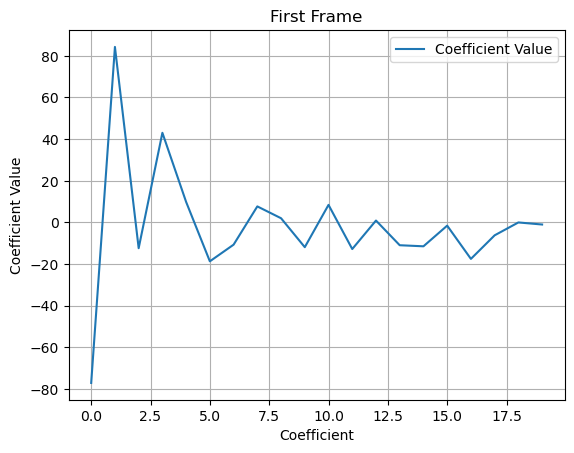

In [50]:
first_frame = audio_segment_mfcc[:, 0]
# plot the first frame by the coefficient index on x-axis and the coefficient value on y-axis
print(min(first_frame), max(first_frame))
# print the index of the coefficient with the minimum value
print(np.argmax(first_frame))
plt.plot(first_frame)
# plot the x-axis title
plt.xlabel('Coefficient')
# plot the y-axis title
plt.ylabel('Coefficient Value')
# plot the title
plt.title('First Frame')
# plot the legend
plt.legend(['Coefficient Value'])
# plot the grid
plt.grid()
# show the plot
plt.show()

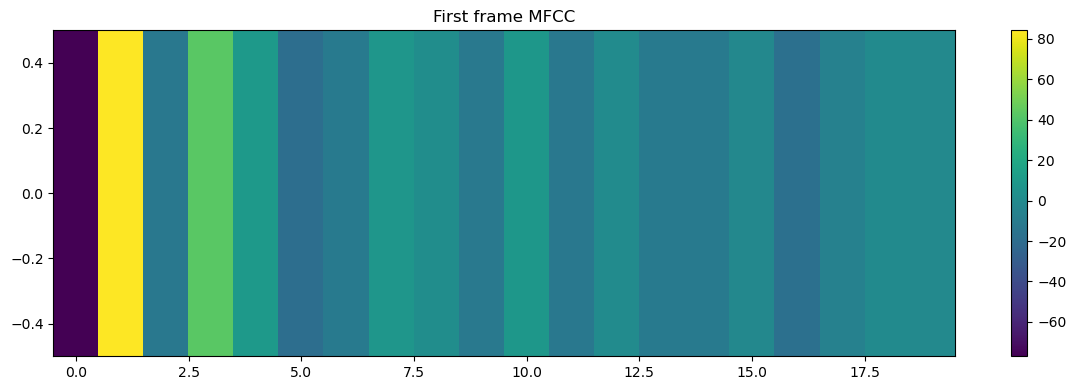

In [51]:
# plot a spectogram but just for the first frame
plt.figure(figsize=(12, 4))
plt.imshow(first_frame.reshape(1,-1), aspect='auto', origin='lower',
           interpolation='nearest')
plt.colorbar()
plt.title('First frame MFCC')
plt.tight_layout()
plt.show()

In [52]:
# Define the model
# Set this to your vocabulary size
vocab_size = 129
mfcc_features = 20  # Number of MFCC features per time step
embed_dim = 16   # 4th root vocab size. previous default was 512  # Embedding size for each token
nhead = 8        # Number of attention heads
nhid = 2048      # Hidden layer size in feed forward network inside transformer
nlayers = 4      # Number of Transformer blocks
max_frame_length = 100 # Maximum sequence length
num_classes = vocab_size  # The output is also a sequence of tokens

In [53]:
# 100 maximum frame length
def preprocess_mfcc(mfcc, max_frame_length=100):
    # Get the current length of the MFCC sequence
    current_length = mfcc.shape[1]

    if current_length > max_frame_length:
        # Truncate the sequence
        mfcc = mfcc[:, :max_frame_length]
    elif current_length < max_frame_length:
        # Pad with zeros
        padding_size = max_frame_length - current_length
        mfcc = F.pad(mfcc, (0, padding_size), "constant", 0)

    # flatten mfcc
    mfcc = mfcc.reshape(1, -1).float()
    mfcc = mfcc.float()
    # mfcc = mfcc.unsqueeze(0)    # Add batch dimension

    return mfcc

In [54]:
# print('original audio segment mfcc shape', audio_segment_mfcc.shape)
# processed_mfcc = preprocess_mfcc(audio_segment_mfcc, max_frame_length=max_frame_length)
# print('processed mfcc shape', processed_mfcc.shape)
# # Now, when you create the model and do a forward pass, it should work with the flattened input
# model = TranscriptionModel(mfcc_features, embed_dim, nhead, nhid, nlayers, max_frame_length, num_classes)
# src = processed_mfcc

In [55]:
# out = model(src)

In [56]:
# model.src_mask

In [57]:
# out.shape

In [58]:
# get the length of our first transcription
print(len(y_train[0]))
print(y_train[0][:10])

31
[2, 3, 4, 1, 5, 6, 1, 7, 1, 3]


In [59]:
min_coeff_value, max_coeff_value = 0, 0

for audio_segment in audio_segments_mfcc:
    for coeff in audio_segment:
        for frame in coeff:
            min_coeff_value = min(min_coeff_value, frame.item())
            max_coeff_value = max(max_coeff_value, frame.item())

print(min_coeff_value, max_coeff_value)

-336.2922058105469 166.37896728515625


In [60]:
audio_segment_mfcc.float().view(1, -1).shape

torch.Size([1, 1600])

# finetune AST for guitar tabs

In [63]:
from transformers import ASTFeatureExtractor
feature_extractor = ASTFeatureExtractor()

In [64]:
import torchaudio

waveform, sampling_rate = torchaudio.load(filepath)
waveform = waveform.squeeze().numpy()

waveform.shape, sampling_rate

((2, 12911032), 48000)

In [65]:
waveform = torch.tensor(waveform)

In [66]:
import torchaudio

# Load the original waveform
waveform, original_sampling_rate = torchaudio.load(filepath)

# Resample to 16,000 Hz
target_sampling_rate = 16000
resampler = torchaudio.transforms.Resample(orig_freq=original_sampling_rate, new_freq=target_sampling_rate)
resampled_waveform = resampler(waveform)

# Check the length of the resampled waveform
print("Length of resampled waveform:", resampled_waveform.shape)


Length of resampled waveform: torch.Size([2, 4303678])


In [67]:
import torch

# Assuming resampled_waveform is your stereo audio with shape [2, 4303678]
# Convert stereo to mono by averaging the two channels
mono_waveform = torch.mean(resampled_waveform, dim=0)

# Check the shape of the mono waveform
print("Length of mono waveform:", mono_waveform.shape)


Length of mono waveform: torch.Size([4303678])


In [68]:
# play the mono waveform
# ipd.Audio(mono_waveform, rate=target_sampling_rate)

In [69]:
inputs = feature_extractor(mono_waveform, sampling_rate=target_sampling_rate, padding="max_length", return_tensors="pt")
# input_values = inputs.input_values
print(inputs.input_values.shape)


torch.Size([1, 1024, 128])


In [70]:
print(f"inputs keys: {list(inputs.keys())}")

print(
    f"Mean: {torch.mean(inputs['input_values']):.3}, Variance: {torch.var(inputs['input_values']):.3}"
)


inputs keys: ['input_values']
Mean: -0.0298, Variance: 0.122


In [71]:
model_id = "MIT/ast-finetuned-audioset-10-10-0.4593"

In [72]:
from transformers import AutoModelForAudioClassification

num_labels = len(id2label)

model = AutoModelForAudioClassification.from_pretrained(
    model_id,
    num_labels=num_labels,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True
)

config.json: 100%|██████████| 26.8k/26.8k [00:00<00:00, 178MB/s]
model.safetensors: 100%|██████████| 346M/346M [00:03<00:00, 107MB/s]  
Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([129]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([129, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [73]:
import torch

with torch.no_grad():
  outputs = model(inputs.input_values)

In [74]:
predicted_class_idx = outputs.logits.argmax(-1).item()
print("Predicted class:", model.config.id2label[predicted_class_idx])


Predicted class: s5f7


# Fine tune model to classify guitar tabs

Right now this AST model only predicts one class in the model (one note).  But my song input was about 30 seconds containing several notes.  How can I make my sequence to sequence classifier predict a sequence rather than a single class?

To adapt the AST model, which is designed for audio classification (predicting a single class for an entire audio segment), to a sequence-to-sequence task like predicting multiple notes in a song, you'll need to make some significant modifications. Sequence-to-sequence models are more complex as they output a sequence of predictions rather than a single label.

Here are the general steps you would follow:

    Segmentation: Divide your audio input into smaller segments where each segment is expected to contain one note or a small, manageable number of notes. The segmentation can be based on time (e.g., every 500ms) or event-driven (e.g., based on onset detection).

    Feature Extraction for Each Segment: For each segment, extract features using the AST feature extractor or any other appropriate feature extraction method.

    Model Architecture Adjustment: Instead of using a classification model like AutoModelForAudioClassification, you would need a model that can handle sequence output. This typically involves models with RNNs (like LSTMs or GRUs) or Transformers.

    Training the Model: Train this new model on your segmented audio with the corresponding sequence of notes as labels. This is a complex task because it requires the model to learn the temporal dependencies between different segments.

    Inference: During inference, you would process each segment through the model and combine the predictions to form the final sequence of notes for the entire song.

Since implementing a sequence-to-sequence model from scratch can be quite challenging, especially for audio data, you might consider looking into existing models that are already designed for similar tasks. For instance, models used in speech-to-text or music transcription might be more aligned with your needs.

If you're set on using the AST model for this task, you would essentially be using it as a feature extractor for each segment and then feeding these features into a separate sequence-to-sequence model. This hybrid approach can leverage the strengths of the AST model in processing audio while still allowing for sequential predictions.

Here is a very simplified pseudocode to illustrate this concept:

```
# Pseudocode
import torch
from your_seq2seq_model import Seq2SeqModel

# Load your sequence-to-sequence model (This needs to be created or adapted for your task)
seq2seq_model = Seq2SeqModel(...)

# Process each segment
for segment in segmented_audio:
    inputs = feature_extractor(segment, ...)
    with torch.no_grad():
        features = model(inputs.input_values)  # Extract features using AST model
    seq_outputs = seq2seq_model(features)     # Process features with your seq2seq model

    # Combine seq_outputs to form the final prediction for the entire song
    # ...

# Final sequence prediction
final_prediction = ...
```

In this approach, Seq2SeqModel is a placeholder for your sequence-to-sequence model, which needs to be developed or adapted for your specific task. Remember, developing such a model requires a good understanding of sequence modeling, a suitable dataset for training, and considerable computational resources.

### Use a seq2seq transformer

In [2]:
from transformers import AutoFeatureExtractor, WhisperModel

model = WhisperModel.from_pretrained("openai/whisper-base")
feature_extractor = AutoFeatureExtractor.from_pretrained("openai/whisper-base")

In [3]:
import torch
from datasets import load_dataset

ds = load_dataset("hf-internal-testing/librispeech_asr_dummy", "clean", split="validation")
inputs = feature_extractor(ds[0]["audio"]["array"], return_tensors="pt")
input_features = inputs.input_features
decoder_input_ids = torch.tensor([[1, 1]]) * model.config.decoder_start_token_id
last_hidden_state = model(input_features, decoder_input_ids=decoder_input_ids).last_hidden_state
list(last_hidden_state.shape)

/home/samus/miniconda3/envs/directml/lib/python3.11/site-packages/datasets/load.py:1429: FutureWarning: The repository for hf-internal-testing/librispeech_asr_dummy contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/hf-internal-testing/librispeech_asr_dummy
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(
It is strongly recommended to pass the `sampling_rate` argument to this function. Failing to do so can result in silent errors that might be hard to debug.


[1, 2, 512]

In [4]:
mel_filter_bank = feature_extractor(y, sampling_rate=sr, return_tensors="pt")

NameError: name 'y' is not defined

In [5]:
my_input = mel_filter_bank.input_features
my_input

NameError: name 'mel_filter_bank' is not defined

In [80]:
first_frame = X_train[0].unsqueeze(0)

In [82]:
decoded_tokens = torch.tensor(y_train[0])
decoded_tokens = decoded_tokens.unsqueeze(0)
decoded_tokens.shape

torch.Size([1, 31])

In [84]:
# lhs = model(my_input, decoder_input_ids=decoded_tokens)
# start_token = 128
lhs = model(my_input, decoder_input_ids=128)

AttributeError: 'int' object has no attribute 'size'

In [94]:
# lhs.loss

AttributeError: 'Seq2SeqModelOutput' object has no attribute 'loss'

In [ ]:
input_features.shape, my_input.shape, type(input_features), type(my_input), type(decoder_input_ids), type(decoded_tokens)

In [83]:
lhs.last_hidden_state.shape

torch.Size([1, 31, 512])

In [84]:
vocab_size

129

To interpret the last_hidden_state tensor from your model and compare its predictions with your expected guitar tabs tokens, you need to convert the output from the model's hidden states to actual token predictions. This typically involves a few steps:

    Project the Hidden States to Token Logits: The last_hidden_state contains hidden representations, not direct token predictions. You need to project these representations onto the space of your possible tokens (e.g., your guitar tabs tokens). This is often done using a linear layer followed by a softmax layer in the model to convert hidden states into logits, representing probabilities for each token in your vocabulary.

    Convert Logits to Token IDs: Choose the token with the highest probability (logit) at each time step. This is typically done using the argmax operation.

    Map Token IDs to Actual Tokens: Convert the predicted token IDs back to the actual tokens (e.g., guitar tab notations) using the tokenizer or mapping you have.

    Compare with Expected Tokens: Compare these predicted tokens with your expected tokens (ground truth) to assess the model's performance.

Here is a general outline of how you might implement this:

In [89]:
import torch

# Assuming model, tokenizer, and lhs are already defined and lhs contains the last hidden state
# Project hidden states to token logits (if your model doesn't already do this)
linear_layer = torch.nn.Linear(512, vocab_size)  # Replace 512 with the size of your hidden states and len(tokenizer) with the size of your vocabulary
logits = linear_layer(lhs.last_hidden_state)

logits.shape



torch.Size([1, 31, 129])

In [ ]:
# Convert logits to token IDs
predicted_token_ids = torch.argmax(logits, dim=-1)

In [88]:
predicted_token_ids.shape

torch.Size([1, 31])

In [91]:
# Map token IDs to actual tokens
for predicted_token_id in predicted_token_ids[0]:
  predicted_note = detokenize_note_simple(predicted_token_id)
  print(predicted_note)

# Now, predicted_tokens contains the predicted sequence
# Compare these with your expected tokens

s5f11
s5f11
s4f10
s3f20
s3f20
s3f20
s3f20
s3f20
s3f20
s3f20
s3f20
s3f20
s3f20
s3f20
s3f20
s3f20
s3f20
s3f20
s3f20
s3f20
s3f20
s3f20
s3f20
s3f20
s3f20
s3f20
s3f20
s3f20
s3f20
s3f20
s3f20


In [93]:
y_train.shape


AttributeError: 'list' object has no attribute 'shape'